In [1]:
# ===============================
# AI-Driven Phishing Email Detection
# Import Required Libraries
# ===============================

# Numerical Computation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string
from bs4 import BeautifulSoup

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\Ashish
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Ashish
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ashish
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\Ashish
[nltk_data]     kumar\AppData\Roaming\nltk_data...


True

In [3]:
df = pd.read_csv("phishing_email.csv")

In [4]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [5]:
df.tail()

,text_combined,label
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1
82485,fastway infofastwaycoza_infofastwaycoza_infofa...,1


In [6]:
df.columns

Index(['text_combined', 'label'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [8]:
df.describe(include="all")

,text_combined,label
count,82486,82486.000000
unique,82078,NaN
top,charity sees need cost dear friend read want f...,NaN
freq,3,NaN
mean,NaN,0.519979
std,NaN,0.499604
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,1.000000


In [9]:
df.dtypes

text_combined    object
label             int64
dtype: object

In [10]:
print(df.columns)

df.head()

Index(['text_combined', 'label'], dtype='object')


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [11]:
print("Dataset Shape:", df.shape)

Dataset Shape: (82486, 2)


In [12]:
df.isnull().sum()

text_combined    0
label            0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
print("Duplicate Emails:", df.duplicated().sum())

Duplicate Emails: 408


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
empty_emails = df[df["text_combined"].str.strip() == ""]
print("Empty Emails:", len(empty_emails))

Empty Emails: 1


In [17]:
df = df[df["text_combined"].str.strip() != ""]

In [18]:
print(df["label"].value_counts())

1    42844
0    39233
Name: label, dtype: int64


In [19]:
print(df["label"].value_counts(normalize=True) * 100)

1    52.199764
0    47.800236
Name: label, dtype: float64


In [20]:
df.dtypes

text_combined    object
label             int64
dtype: object

In [21]:
df.reset_index(drop=True, inplace=True)

In [22]:
print(df.shape)

df.head()

(82077, 2)


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


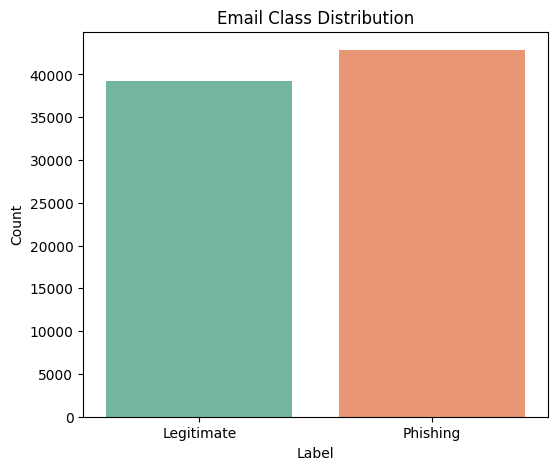

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="label",
    palette="Set2"
)

plt.title("Email Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks([0,1],["Legitimate","Phishing"])

plt.show()

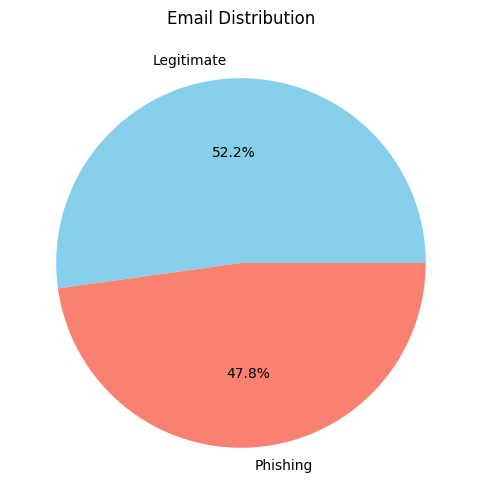

In [24]:
plt.figure(figsize=(6,6))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Legitimate","Phishing"],
    colors=["skyblue","salmon"]
)

plt.ylabel("")
plt.title("Email Distribution")
plt.show()

In [25]:
df["email_length"] = df["text_combined"].apply(len)

In [26]:
df[["text_combined","email_length"]].head()

,text_combined,email_length
0,hpl nom may 25 2001 see attached file hplno 52...,65
1,nom actual vols 24 th forwarded sabrae zajac h...,1071
2,enron actuals march 30 april 1 201 estimated a...,148
3,hpl nom may 30 2001 see attached file hplno 53...,65
4,hpl nom june 1 2001 see attached file hplno 60...,65


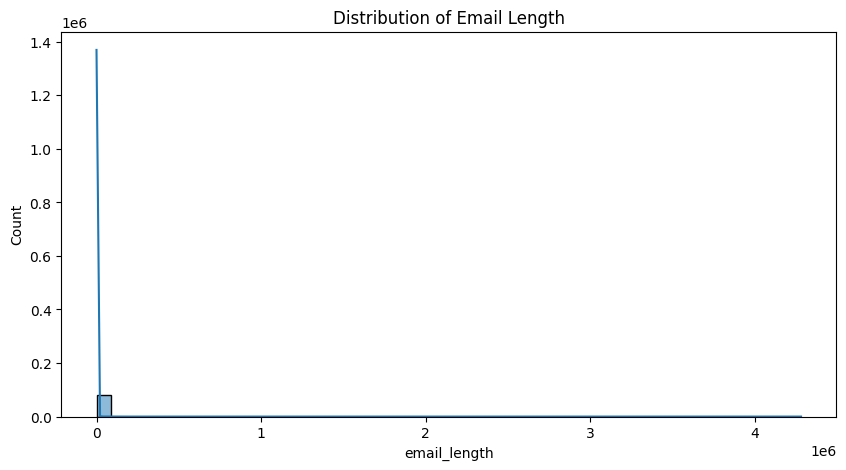

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["email_length"],
    bins=50,
    kde=True
)

plt.title("Distribution of Email Length")

plt.show()

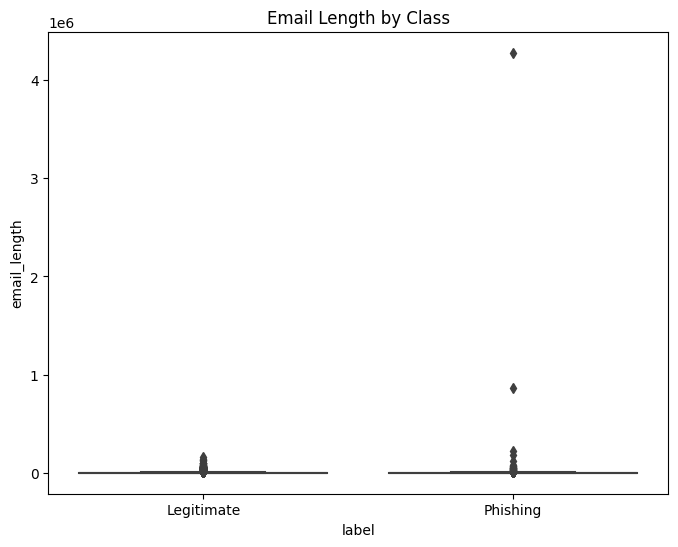

In [28]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="label",
    y="email_length"
)

plt.xticks([0,1],["Legitimate","Phishing"])

plt.title("Email Length by Class")

plt.show()

In [29]:
## 6. Outlier Detection

In [30]:
df["email_length"].describe()

count    8.207700e+04
mean     1.290512e+03
std      1.553516e+04
min      3.000000e+00
25%      2.760000e+02
50%      5.580000e+02
75%      1.339000e+03
max      4.279526e+06
Name: email_length, dtype: float64

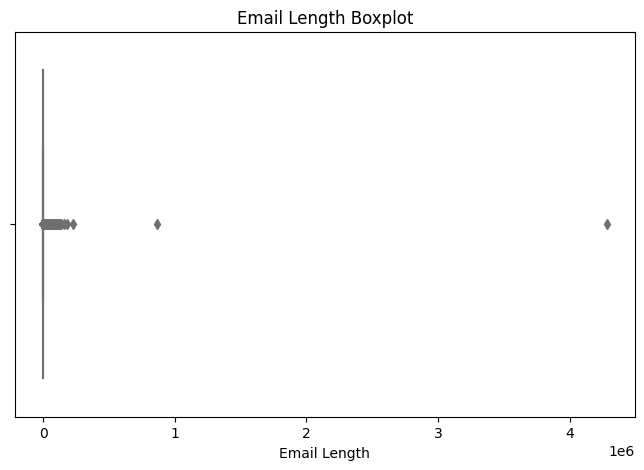

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["email_length"],
    color="skyblue"
)

plt.title("Email Length Boxplot")
plt.xlabel("Email Length")
plt.show()

In [32]:
Q1 = df["email_length"].quantile(0.25)
Q3 = df["email_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1 : 276.0
Q3 : 1339.0
IQR: 1063.0
Lower Bound: -1318.5
Upper Bound: 2933.5


In [33]:
outliers = df[
    (df["email_length"] < lower_bound) |
    (df["email_length"] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 5597


In [34]:
percentage = len(outliers) / len(df) * 100

print(f"Outliers: {percentage:.2f}%")

Outliers: 6.82%


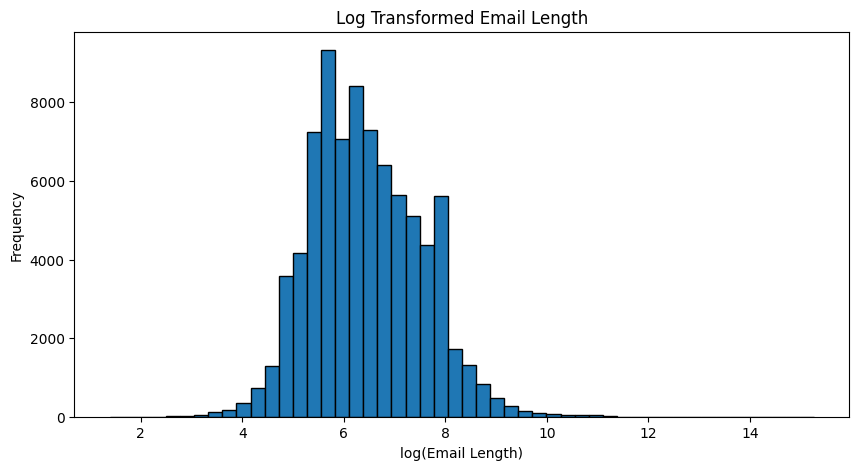

In [35]:
plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(df["email_length"]),
    bins=50,
    edgecolor="black"
)

plt.title("Log Transformed Email Length")
plt.xlabel("log(Email Length)")
plt.ylabel("Frequency")

plt.show()

In [36]:
## 7. Text Preprocessing

In [51]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()


In [52]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    FILE_EXTENSIONS = {
        "pdf", "xls", "xlsx", "doc", "docx",
        "ppt", "pptx", "zip", "rar", "exe",
        "csv", "jpg", "jpeg", "png", "gif"
    }
    words = [
        word if word in FILE_EXTENSIONS else lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [53]:
sample = df.loc[0, "text_combined"]

print("Original Email:\n")
print(sample)

print("\n" + "="*80 + "\n")

print("Cleaned Email:\n")
print(clean_text(sample))

Original Email:

hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


Cleaned Email:

hpl nom may see attached file hplno xls hplno xls


In [54]:
df["clean_text"] = df["text_combined"].apply(clean_text)

In [56]:
df[["text_combined", "clean_text"]].head()

,text_combined,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xls hplno xls
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xls hplno xls
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xls hplno...


In [57]:
for i in range(3):

    print("=" * 100)

    print("Original Email:\n")
    print(df.loc[i, "text_combined"])

    print("\n")

    print("Cleaned Email:\n")
    print(df.loc[i, "clean_text"])

    print("\n")

Original Email:

hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


Cleaned Email:

hpl nom may see attached file hplno xls hplno xls


Original Email:

nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen ponton 05 29 2001 08 37 davilal txu com cstonel txu com mjones 7 txu com hpl scheduling enron com liz bellamy enron com szajac enron com cc subject nom actual vols 24 th agree nomination 33 750 forwarded eileen ponton houston pefs pec 05 29 01 08 36 charlie stone eileen ponton melissa jones com hpl scheduling enron com liz bellamy enron com szajac enron com 05 25 01 subject nom actual vols 24 th 04 23 pm agree nominated volume records reflect following nom schedule 30 rate eff 0900 hrs hour beginning 1400 hrs 6 250 60 rate eff 1400 hrs hour beginning 1700 hrs 7 500 30 rate eff 1700 hrs hour beginning 0900 hrs 20 000 total nominated 33 750 please review source data let us know agree thanks ccs eileen ponton

In [58]:
## 8. Feature Engineering

In [59]:
df["char_count"] = df["text_combined"].str.len()

In [60]:
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

In [61]:
df["sentence_count"] = df["text_combined"].apply(
    lambda x: len(re.findall(r"[.!?]", str(x))) + 1
)

In [62]:
df["url_count"] = df["text_combined"].apply(
    lambda x: len(re.findall(r"http[s]?://|www\.", str(x)))
)

In [63]:
df["email_count"] = df["text_combined"].apply(
    lambda x: len(re.findall(r"\S+@\S+", str(x)))
)

In [64]:
df["digit_count"] = df["text_combined"].apply(
    lambda x: sum(char.isdigit() for char in str(x))
)

In [65]:
df["uppercase_count"] = df["text_combined"].apply(
    lambda x: sum(char.isupper() for char in str(x))
)
df["uppercase_count"] = df["text_combined"].apply(
    lambda x: sum(char.isupper() for char in str(x))
)

In [66]:
df["exclamation_count"] = df["text_combined"].str.count("!")
df["question_count"] = df["text_combined"].str.count(r"\?")


In [74]:
df["special_char_count"] = df["text_combined"].apply(
    lambda x: len(re.findall(r"[^\w\s]", str(x)))
)

In [75]:
suspicious_words = [
    "verify",
    "click",
    "login",
    "password",
    "bank",
    "urgent",
    "limited",
    "winner",
    "account",
    "security",
    "update",
    "confirm",
    "reward",
    "gift",
    "invoice",
    "payment"
]

def suspicious_count(text):
    words = text.lower().split()
    return sum(word in suspicious_words for word in words)

df["suspicious_word_count"] = df["text_combined"].apply(suspicious_count)

In [76]:
feature_columns = [
    "char_count",
    "word_count",
    "sentence_count",
    "url_count",
    "email_count",
    "digit_count",
    "uppercase_count",
    "special_char_count",
    "exclamation_count",
    "question_count",
    "suspicious_word_count"
]

df[feature_columns].head()

,char_count,word_count,sentence_count,url_count,email_count,digit_count,uppercase_count,special_char_count,exclamation_count,question_count,suspicious_word_count
0,65,10,1,0,0,12,0,0,0,0,0
1,1071,152,1,0,0,135,0,0,0,0,0
2,148,17,1,0,0,28,0,0,0,0,0
3,65,10,1,0,0,12,0,0,0,0,0
4,65,10,1,0,0,11,0,0,0,0,0


In [77]:
df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,82077.0,1290.511581,15535.158262,3.0,276.0,558.0,1339.0,4279526.0
word_count,82077.0,142.072042,497.558503,0.0,33.0,68.0,164.0,98068.0
sentence_count,82077.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
url_count,82077.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
email_count,82077.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
digit_count,82077.0,75.306541,2604.270450,0.0,16.0,27.0,52.0,740726.0
uppercase_count,82077.0,0.001036,0.259544,0.0,0.0,0.0,0.0,74.0
special_char_count,82077.0,0.000037,0.006046,0.0,0.0,0.0,0.0,1.0
exclamation_count,82077.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
question_count,82077.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


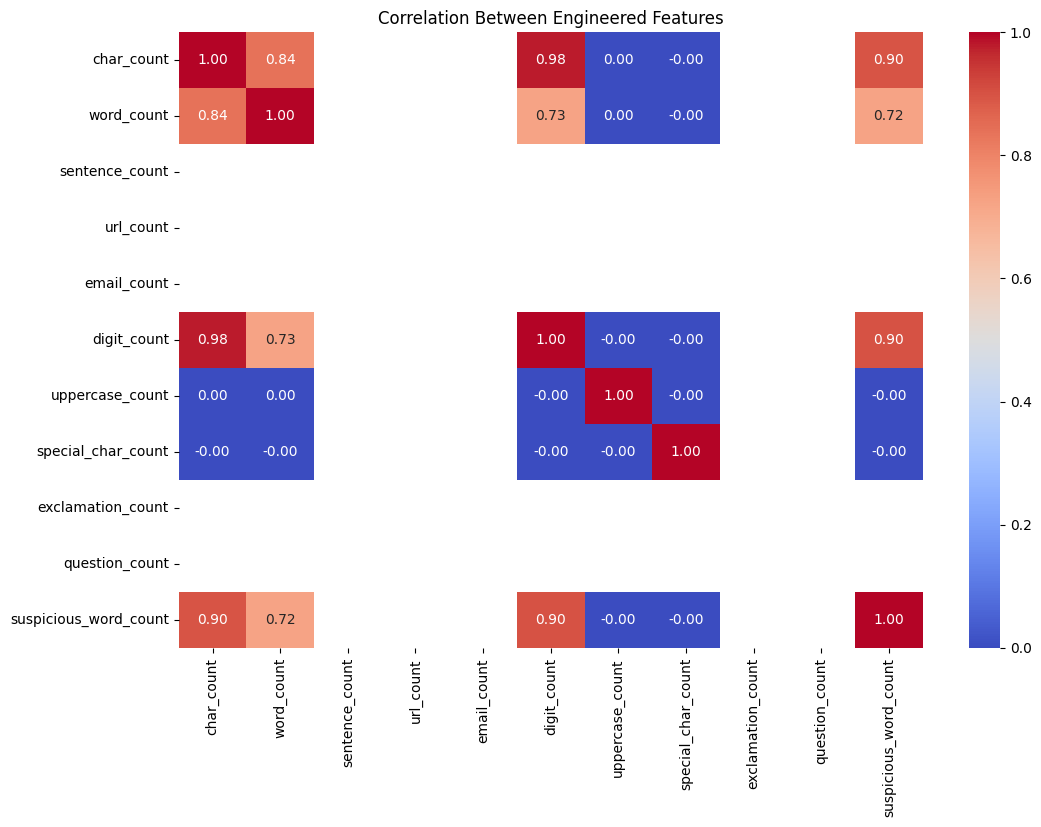

In [78]:
plt.figure(figsize=(12,8))

corr = df[feature_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Engineered Features")
plt.show()

In [79]:
feature_means = df.groupby("label")[feature_columns].mean().T

feature_means.columns = ["Legitimate", "Phishing"]

feature_means

,Legitimate,Phishing
char_count,1541.456147,1060.717253
word_count,180.954630,106.466576
sentence_count,1.000000,1.000000
url_count,0.000000,0.000000
email_count,0.000000,0.000000
digit_count,82.858028,68.391513
uppercase_count,0.000127,0.001867
special_char_count,0.000076,0.000000
exclamation_count,0.000000,0.000000
question_count,0.000000,0.000000


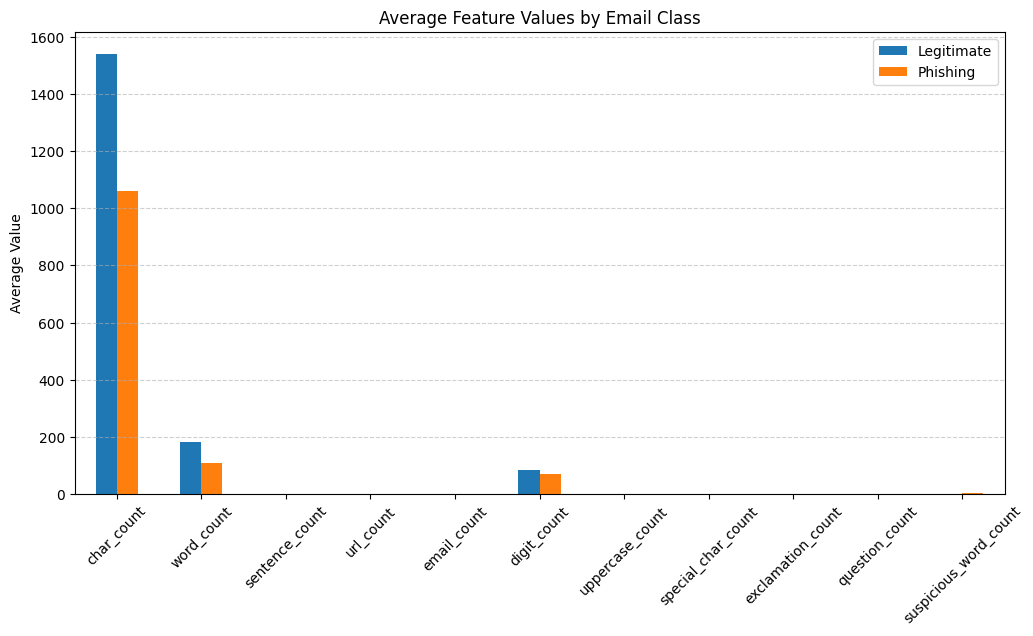

In [80]:
feature_means.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Feature Values by Email Class")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [82]:
#TF-IDF Feature Extraction

In [83]:
X_text = df["clean_text"]

y = df["label"]

In [84]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [85]:
X_tfidf = tfidf.fit_transform(X_text)

In [86]:
print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (82077, 5000)


In [87]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 5000


In [88]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])

['aa' 'aaron' 'ab' 'abacha' 'abandoned' 'abidjan' 'ability' 'able'
 'abroad' 'absolute' 'absolutely' 'abstract' 'absurd' 'absurd episode'
 'abuse' 'ac' 'ac uk' 'academic' 'accept' 'acceptable']


In [89]:
tfidf_df = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aa,aaron,ab,abacha,abandoned,abidjan,ability,able,abroad,absolute,...,zealand,zero,zimbabwe,zimin,zip,zone,zoo,zoo mistress,zvlllneumpythonorg,zvlllneumpythonorg unsubscribe
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [90]:
total_elements = X_tfidf.shape[0] * X_tfidf.shape[1]
non_zero = X_tfidf.nnz

print("Total Elements :", total_elements)
print("Non-zero Values:", non_zero)
print("Sparsity:", (1 - non_zero / total_elements) * 100)

Total Elements : 410385000
Non-zero Values: 6144552
Sparsity: 98.50273474907708


In [91]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [92]:
X = X_tfidf
y = df["label"]

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (65661, 5000)
Testing Data  : (16416, 5000)


In [94]:
## 10. Model Training

In [95]:
results = []

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Train model
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

# Prediction
y_pred_lr = lr.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

# Save results
results.append([
    "Logistic Regression",
    accuracy,
    precision,
    recall,
    f1
])

Accuracy : 0.9800804093567251
Precision: 0.9782961931290622
Recall   : 0.9836620375773135
F1 Score : 0.9809717777131219

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



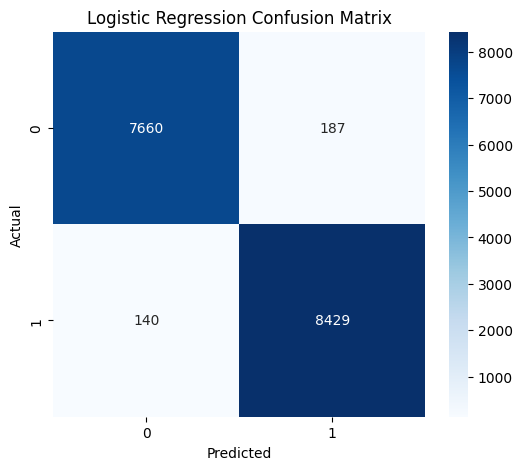

In [97]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Accuracy : 0.9523026315789473
Precision: 0.9789616141732284
Recall   : 0.9285797642665422
F1 Score : 0.9531053482661556
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7847
           1       0.98      0.93      0.95      8569

    accuracy                           0.95     16416
   macro avg       0.95      0.95      0.95     16416
weighted avg       0.95      0.95      0.95     16416



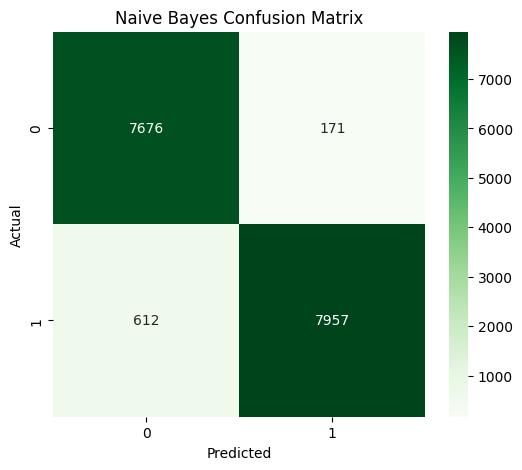

In [98]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print(classification_report(y_test, y_pred_nb))

results.append([
    "Naive Bayes",
    accuracy,
    precision,
    recall,
    f1
])

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy : 0.9838572124756335
Precision: 0.9839160839160839
Recall   : 0.9851791340879916
F1 Score : 0.9845472039185957
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.99      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



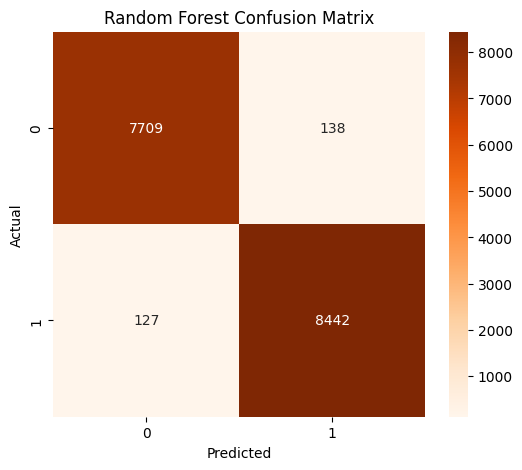

In [108]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print(classification_report(y_test, y_pred_rf))

results.append([
    "Random Forest",
    accuracy,
    precision,
    recall,
    f1
])

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy : 0.9770955165692008
Precision: 0.9779488974448722
Recall   : 0.9781771501925546
F1 Score : 0.9780630105017504
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



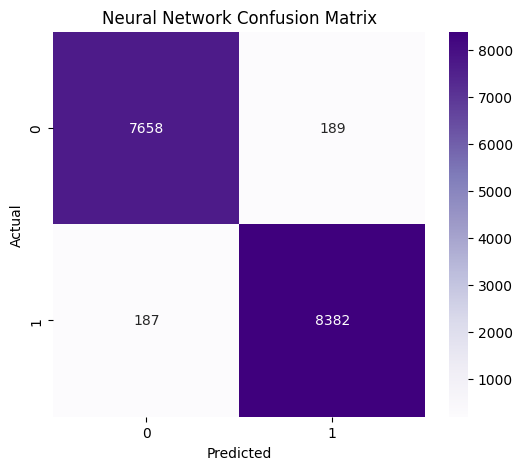

In [100]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_mlp)
precision = precision_score(y_test, y_pred_mlp)
recall = recall_score(y_test, y_pred_mlp)
f1 = f1_score(y_test, y_pred_mlp)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print(classification_report(y_test, y_pred_mlp))

results.append([
    "Neural Network",
    accuracy,
    precision,
    recall,
    f1
])

cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [109]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.980080,0.978296,0.983662,0.980972
1,Naive Bayes,0.952303,0.978962,0.928580,0.953105
2,Random Forest,0.983857,0.983916,0.985179,0.984547
3,Neural Network,0.977096,0.977949,0.978177,0.978063
4,Random Forest,0.983857,0.983916,0.985179,0.984547


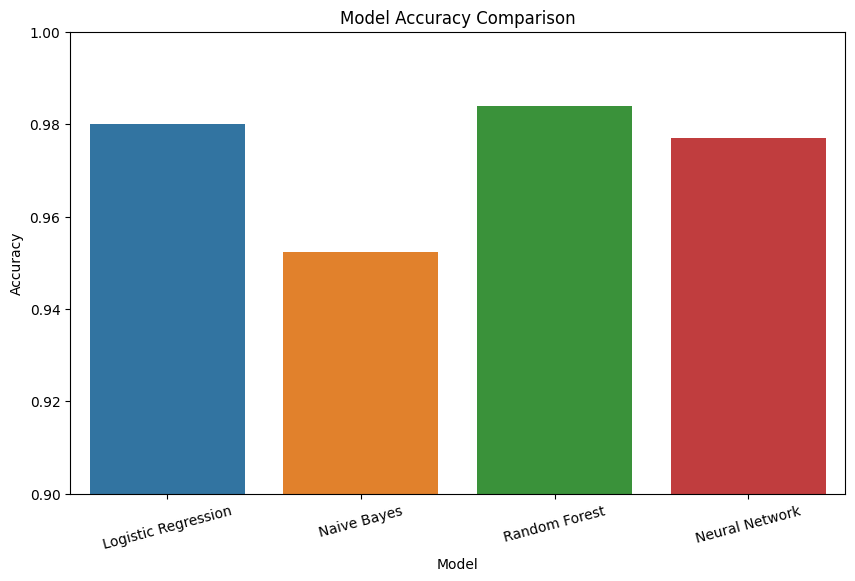

In [110]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0.9, 1.0)
plt.xticks(rotation=15)

plt.show()

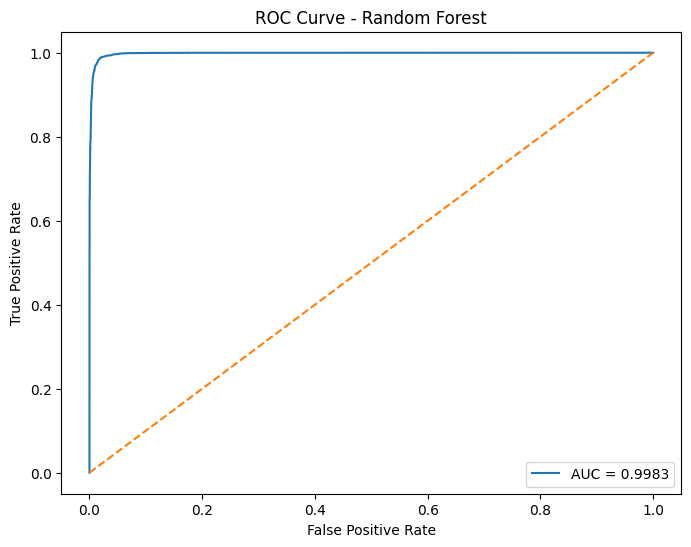

In [113]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability scores
y_prob = rf.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

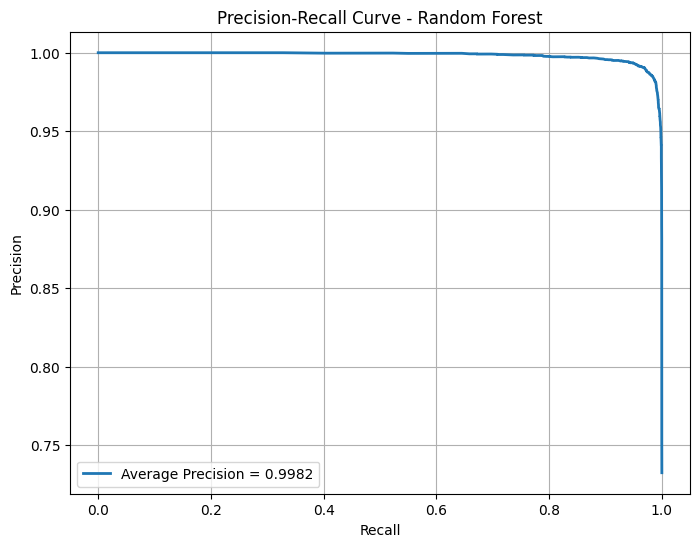

In [114]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Prediction probabilities
y_scores = rf.predict_proba(X_test)[:, 1]

# Precision-Recall values
precision, recall, _ = precision_recall_curve(y_test, y_scores)

# Average Precision
ap = average_precision_score(y_test, y_scores)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2,
         label=f"Average Precision = {ap:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [115]:
feature_importance = pd.DataFrame({
    "Feature": tfidf.get_feature_names_out(),
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
4953,wrote,0.029534
339,aug,0.022040
1450,enron,0.021441
3342,pm,0.014139
4449,thanks,0.013319
2520,list,0.012163
2128,im,0.010377
4843,wed aug,0.010254
2842,money,0.009351
656,cc,0.009230


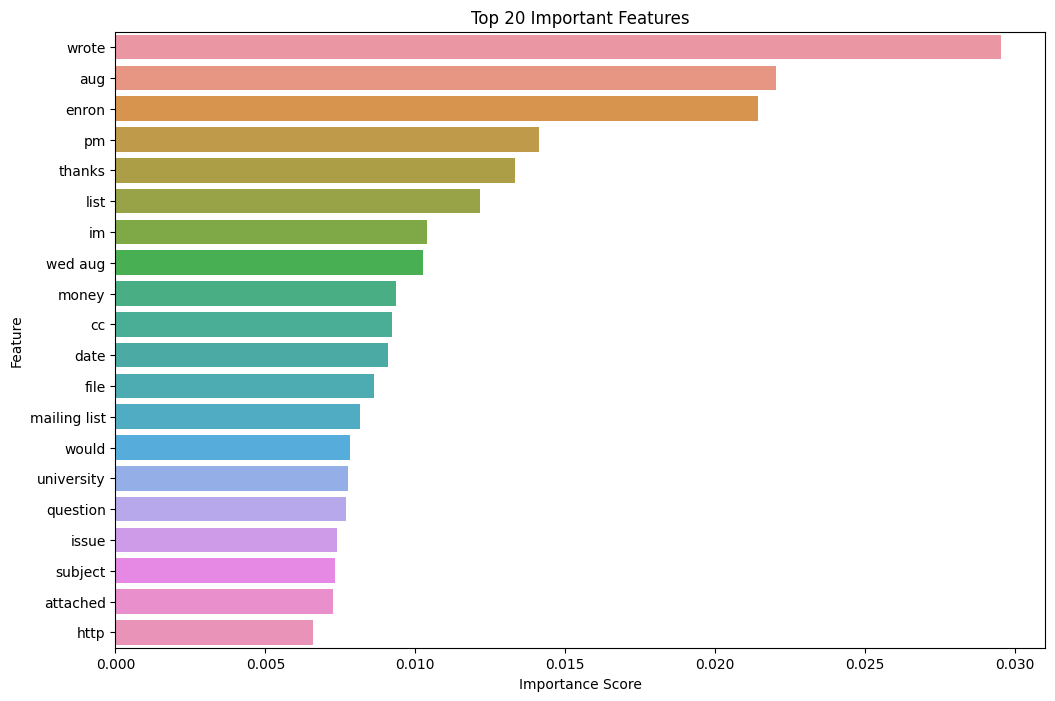

In [116]:
plt.figure(figsize=(12,8))

top20 = feature_importance.head(20)

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [117]:
import joblib

joblib.dump(rf, "random_forest_phishing_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [118]:
def predict_email(email):

    cleaned = clean_text(email)

    vector = tfidf.transform([cleaned])

    prediction = rf.predict(vector)[0]

    probability = rf.predict_proba(vector)[0]

    confidence = max(probability) * 100

    if prediction == 1:
        print("Prediction : PHISHING EMAIL")
    else:
        print("Prediction : LEGITIMATE EMAIL")

    print(f"Confidence : {confidence:.2f}%")

In [119]:
email = """
Dear Customer,

Your account has been suspended.

Click the link below immediately to verify your account.

http://secure-login-update.com

Failure to verify within 24 hours will permanently disable your account.

Thank you.
"""

predict_email(email)

Prediction : PHISHING EMAIL
Confidence : 100.00%


In [131]:
email = """
Hi there,


On August 7, 2026, we're updating our Terms of Use and Privacy Policy to keep pace with new features like Supercomputer Agent, developer access, and face and voice tools. Here's what matters most:


Privacy Policy

Face and voice features. A new Biometric Information section explains exactly how these features work: biometric data is used only to provide the feature you requested and is never stored.
Account deletion. Delete your account and you get a 30-day window to change your mind. After that, your content is permanently removed from our systems.
Terms of Use

Price changes. Any price increase applies only from your next renewal term, with at least 30 days' email notice. Your current term's price never changes.
Failed payments. If a payment fails, you'll have at least 7 days (usually 14) to fix it before it affects your subscription.
Refund protections. If we ever discontinue the Service or a paid feature you're using, we'll refund the unused part of what you paid, including unused credits.
We've also clarified how credits, "Unlimited" plan fair-use limits, AI model updates, and developer access work. The details are in the full documents below.


Read the full documents: Terms of Use · Privacy Policy


The next time you visit Higgsfield, we'll ask you to review and accept the updated terms. It only takes a moment. Continuing to use Higgsfield after August 7, 2026 means the updated terms apply.


The Higgsfield Team
"""

predict_email(email)

Prediction : PHISHING EMAIL
Confidence : 52.50%
